In [3]:
import matplotlib.pyplot as plt

import pydpeet as eet

# Table of Content

1. [Convert](#convert)
2. [Merge](#Merge)
3. [Sequence](#seqence)
4. [add SOC](#soc)
5. [add Capacity](#capacity)
6. Internal Resistance
7. [SOH-C/SOH-R](#soh)
8. [OCV/DVA/ICA](#ocv)


## Convert

In [2]:
Data = eet.convert_file(config="Neware", input_path=r"..\..\res\raw\Cal_Ageing_Checkup1.xlsx")
Data.head()

AttributeError: module 'pydpeet' has no attribute 'convert_file'

## Merge

In [3]:
# Datas = eet.convert_files_in_directory(config = 'Neware', input_path = r'..\..\res\raw')

In [4]:
# fig, ax = plt.subplots(1,len(Datas), figsize=(10,5))
# ax = ax.flatten()
# for i, (data, ax_i) in enumerate(zip(Datas, ax)):
#     data.plot(x="Absolute Time[yyyy-mm-dd hh:mm:ss]", y="Voltage[V]", ax=ax_i)
#     ax_i.set_title(f"Test {i+1}")
#     ax_i.set_ylabel("Voltage[V]")
#     ax_i.set_xlabel("Absolute Time")

In [5]:
Datas = eet.process.merge.series._sort_dfs(Datas)
Merged_Data = eet.process.merge.series.run_series(Datas)
Merged_Data.head()

NameError: name 'Datas' is not defined

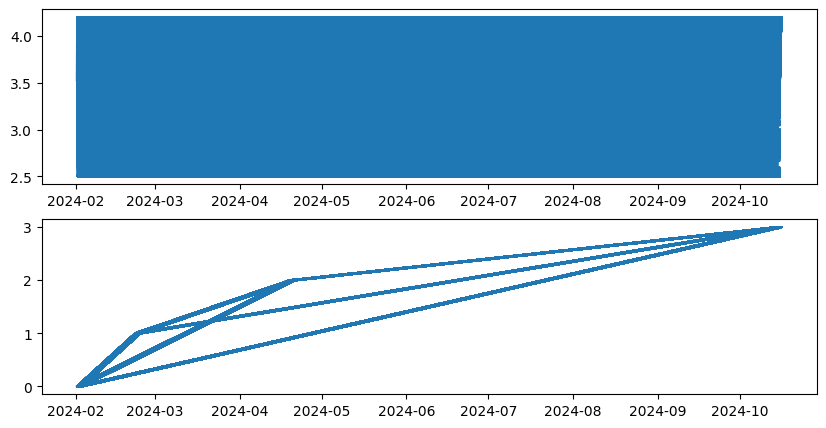

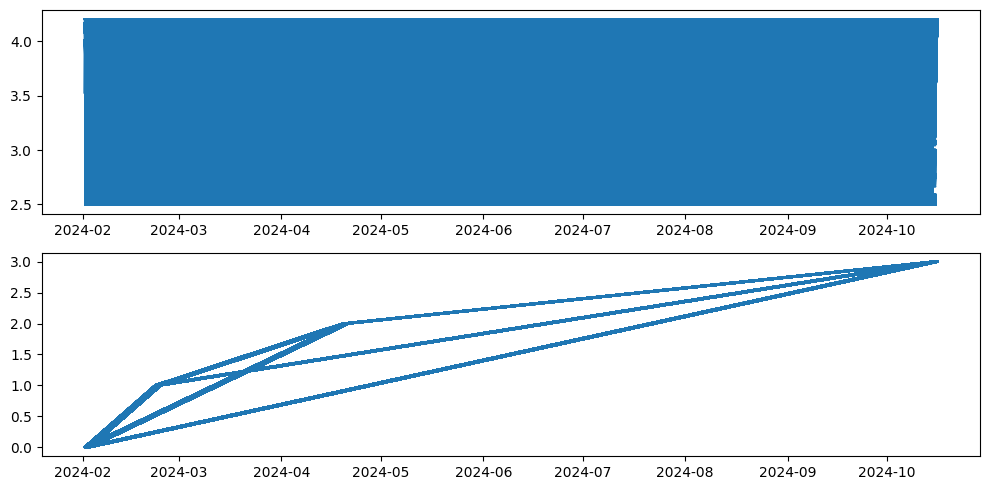

In [ ]:
import matplotlib as mpl

mpl.rcParams["agg.path.chunksize"] = 20000  # z.B. 10k–100k ausprobieren
mpl.rcParams["path.simplify"] = True
mpl.rcParams["path.simplify_threshold"] = 1.0


fig, ax = plt.subplots(2, figsize=(10, 5))
ax[0].plot(Merged_Data["Date_Time"], Merged_Data["Voltage[V]"])
ax[1].plot(Merged_Data["Date_Time"], Merged_Data["TestIndex"])
fig.tight_layout()
plt.show()

## Seqence

Input Warning: Using EXAMPLE_STEP_ANALYZER_PRIMITIVES_CONFIG as fallback configuration. Manual Parameters will be kept.
Input Warning: Dropping NaN values in 'Test_Time[s]', dropping duplicates and sorting 'Test_Time[s]' column.
    0.6979s precompiling step_analyzer_primitives and df_primitives_correction
detecting segments in dataframe of size 163770...
    0.0016s calculating Power[W]
    0.0023s separating Voltage[V] into segments using incremental linear fit
    0.0016s separating Current[A] into segments using incremental linear fit
    0.0016s separating Power[W] into segments using incremental linear fit
    0.0022s adding Length_Segment_Voltage[V] to calculate the dominating segments
    0.0022s adding Length_Segment_Current[A] to calculate the dominating segments
    0.0022s adding Length_Segment_Power[W] to calculate the dominating segments
    0.0063s suppressing smaller segments
    0.0310s attempting to merge neighboring segments
    0.0851s fine tuning width of constant 

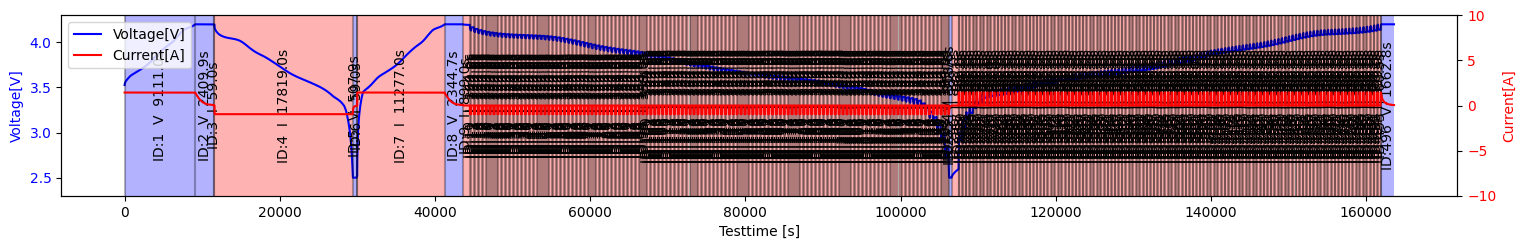

In [8]:
Sequenced_Data = eet.process.sequence.step_analyzer.step_analyzer_primitives(Data)
from pydpeet.process.sequence.utils.visualize.visualize_data import visualize_phases

visualize_phases(
    dataframe=Sequenced_Data,
    # ...
)
plt.show()

## SOC

In [12]:
Battery_Config = eet.process.analyze.am23nmc


# todo: is it possible to probide acces to the Batemo database and fetch battery configs directly from there?
# todo: or we download it and provide the databse directly?

eet.process.analyze.add_soc(Sequenced_Data, standard_method=True, config=Battery_Config)

TypeError: add_soc() missing 1 required positional argument: 'df_primitives'

In [ ]:
Tets = eet.process.analyze.add_soc(Sequenced_Data)
# plot

AttributeError: module 'pydpeet.process.analyze' has no attribute 'add_soc'

## Capacity

In [ ]:
Merged_Data.append(eet.process.add_Capacity(Merged_Data))
# plot

## SOH

In [ ]:
Merged_Data.append(eet.process.add_soh(Merged_Data, method="C"))

In [ ]:
Merged_Data.append(eet.process.add_soh(Merged_Data, method="R"))

## OCV

In [ ]:
Merged_Data.append(eet.process.OCV(Merged_Data))